Importing the necessary packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import *
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import os
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder
import statsmodels.api as st
from scipy.stats import zscore
from sklearn.ensemble import RandomForestRegressor
from matplotlib.patches import Rectangle
from scipy.stats import mannwhitneyu, gaussian_kde
from matplotlib.patches import Patch

In [2]:
os.chdir("C:/Users/eyobh/Downloads") #change the working directory to the files locationn

Reading the the dataset

In [3]:
df = pd.read_csv('medical-charges.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Descriptive statics of the dataset

In [4]:
# Numeric summary without NaNs
desc_num_clean = df.describe().dropna(axis=1)

# Categorical summary without NaNs
desc_cat_clean = df.describe(include=['object']).dropna(axis=1)

# Display separately
print("Numeric Summary :")
print(desc_num_clean)

print("\nCategorical Summary:")
print(desc_cat_clean)


Numeric Summary :
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010

Categorical Summary:
         sex smoker     region
count   1338   1338       1338
unique     2      2          4
top     male     no  southeast
freq     676   1064        364


Encoding the categorical variables

In [5]:
df['smoker_code'] = [ 1 if i == 'yes' else 0 for i in df.smoker]
df['sex_code'] = [ 1 if i == 'male' else 0 for i in df.sex]
region_dummies = pd.get_dummies(df['region'], prefix='region', drop_first=True, dtype = int)

# 3. Merge back into your DataFrame
df = pd.concat([df, region_dummies], axis=1)

# 4. Inspect the new columns
print(df[['region'] + list(region_dummies.columns)].head())


      region  region_northwest  region_southeast  region_southwest
0  southwest                 0                 0                 1
1  southeast                 0                 1                 0
2  southeast                 0                 1                 0
3  northwest                 1                 0                 0
4  northwest                 1                 0                 0


In [6]:
df.head()

,age,sex,bmi,children,smoker,region,charges,smoker_code,sex_code,region_northwest,region_southeast,region_southwest
0,19,female,27.900,0,yes,southwest,16884.92400,1,0,0,0,1
1,18,male,33.770,1,no,southeast,1725.55230,0,1,0,1,0
2,28,male,33.000,3,no,southeast,4449.46200,0,1,0,1,0
3,33,male,22.705,0,no,northwest,21984.47061,0,1,1,0,0
4,32,male,28.880,0,no,northwest,3866.85520,0,1,1,0,0


In [7]:
df.shape

(1338, 12)

Checking for  missing(NA) values

In [8]:
df.isna().sum()

age                 0
sex                 0
bmi                 0
children            0
smoker              0
region              0
charges             0
smoker_code         0
sex_code            0
region_northwest    0
region_southeast    0
region_southwest    0
dtype: int64

Checking for duplicates

In [9]:
df.duplicated().sum()

1

Remove duplicate rows in place, keeping the first occurrence

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.shape

(1337, 12)

In [12]:
data = df[['age', 'bmi', 'children', 'charges', 'smoker_code', 'sex_code',]]

Univariate analysis

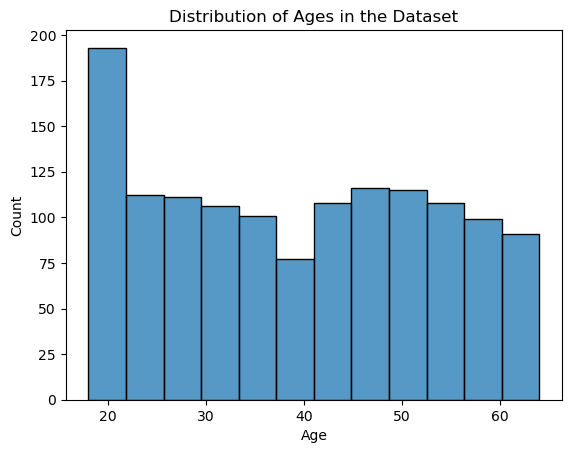

In [13]:
sns.histplot(data = df, x = 'age')
plt.title("Distribution of Ages in the Dataset")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

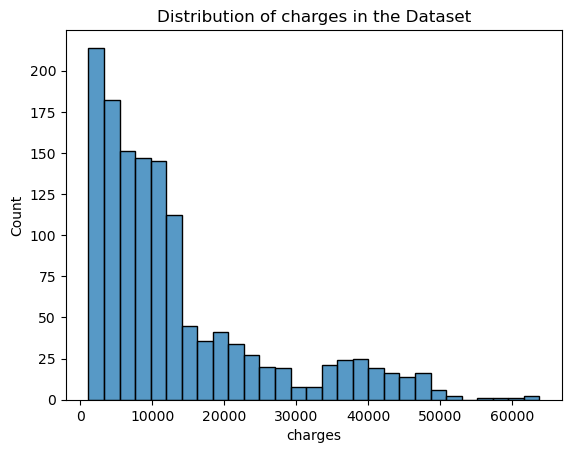

In [14]:
sns.histplot(data = df, x = 'charges')
plt.title("Distribution of charges in the Dataset")
plt.xlabel("charges")
plt.ylabel("Count")
plt.show()

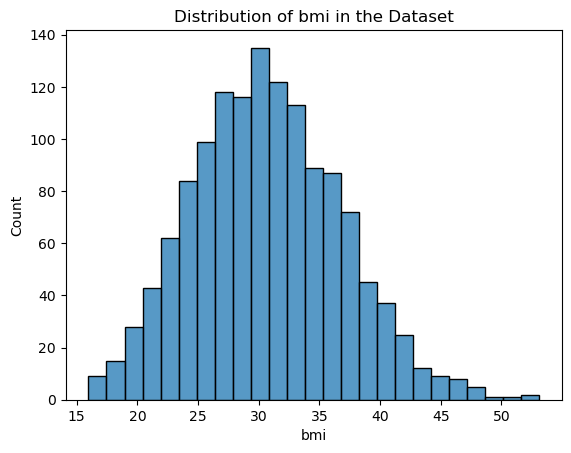

In [15]:
sns.histplot(data = df, x = 'bmi')
plt.title("Distribution of bmi in the Dataset")
plt.xlabel("bmi")
plt.ylabel("Count")
plt.show()

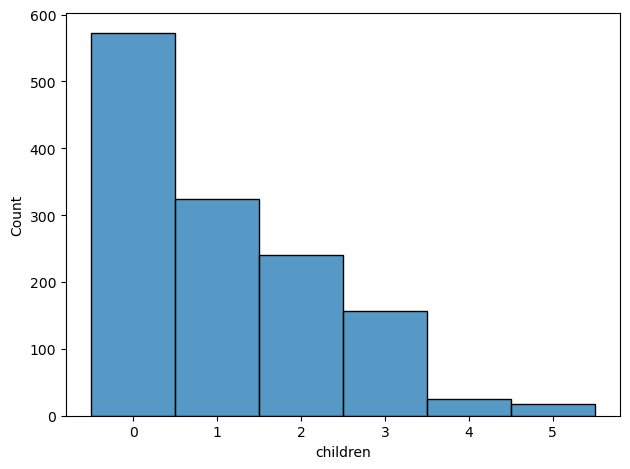

In [16]:
sns.histplot(
    data=df,
    x="children",
    discrete=True,   # treat x as categorical/discrete
    shrink=1.0       # use 100% of the bin width for each bar
)

plt.tight_layout()
plt.show()

Bivariate analysis

Text(0.5, 1.0, 'Age vs charges scatter plot')

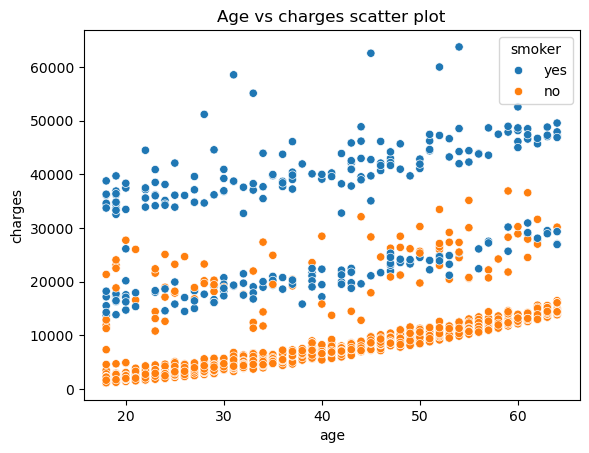

In [17]:
sns.scatterplot(x = 'age', y= 'charges', hue = 'smoker', data = df)
plt.title('Age vs charges scatter plot')

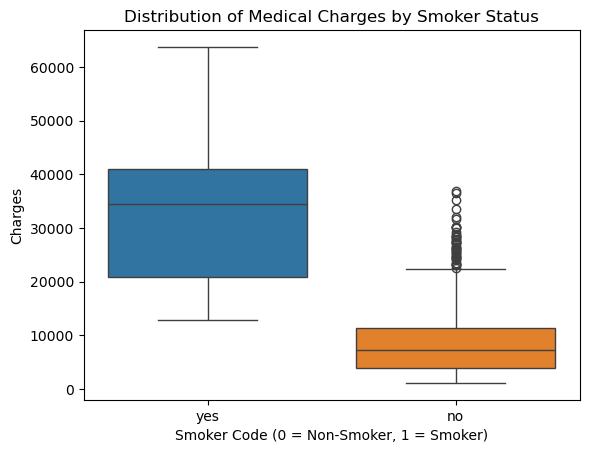

In [18]:
sns.boxplot(x = 'smoker',y = 'charges', data = df, hue = 'smoker')
plt.title("Distribution of Medical Charges by Smoker Status")
plt.xlabel("Smoker Code (0 = Non‑Smoker, 1 = Smoker)")
plt.ylabel("Charges")
plt.show()

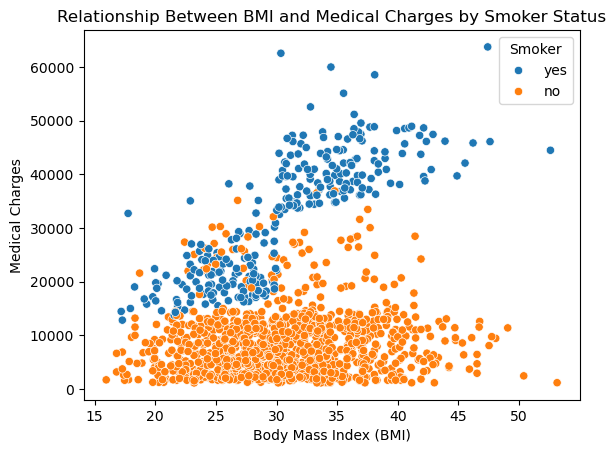

In [19]:
sns.scatterplot(x = 'bmi', y= 'charges', hue = 'smoker', data = df)
plt.title("Relationship Between BMI and Medical Charges by Smoker Status")
plt.xlabel("Body Mass Index (BMI)")
plt.ylabel("Medical Charges")
plt.legend(title="Smoker")
plt.show()

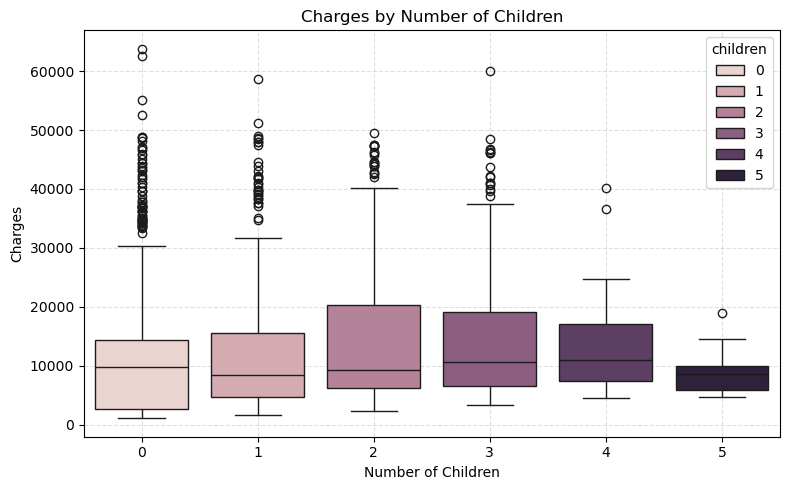

In [20]:
plt.figure(figsize=(8,5))
sns.boxplot(x='children', y='charges', data=df, hue = 'children')
plt.title("Charges by Number of Children")
plt.xlabel("Number of Children")
plt.ylabel("Charges")
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


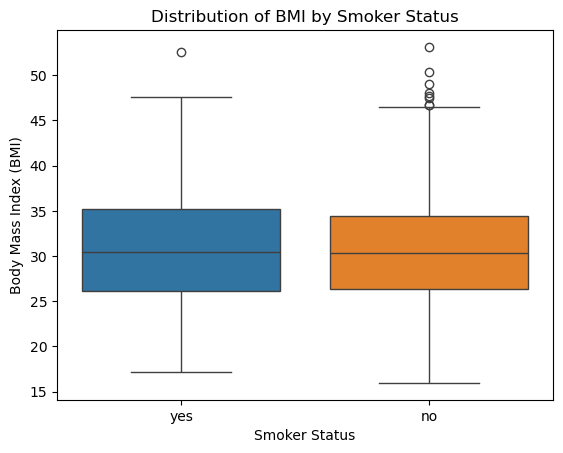

In [21]:
sns.boxplot(x = 'smoker',y = 'bmi', data = df, hue = 'smoker')
plt.title("Distribution of BMI by Smoker Status")
plt.xlabel("Smoker Status")
plt.ylabel("Body Mass Index (BMI)")
plt.show()

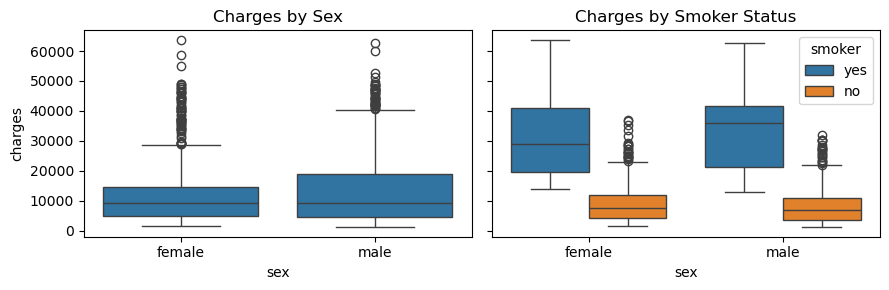

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3), sharey=True)

# Boxplot 1: charges by sex
sns.boxplot(data=df, x='sex', y='charges', ax=axes[0])
axes[0].set_title('Charges by Sex')

# Boxplot 2: charges by smoker status
sns.boxplot(data=df, x='sex', y='charges', hue = 'smoker',ax=axes[1])
axes[1].set_title('Charges by Smoker Status')

# Improve layout
plt.tight_layout()
plt.show()

<Axes: xlabel='smoker', ylabel='charges'>

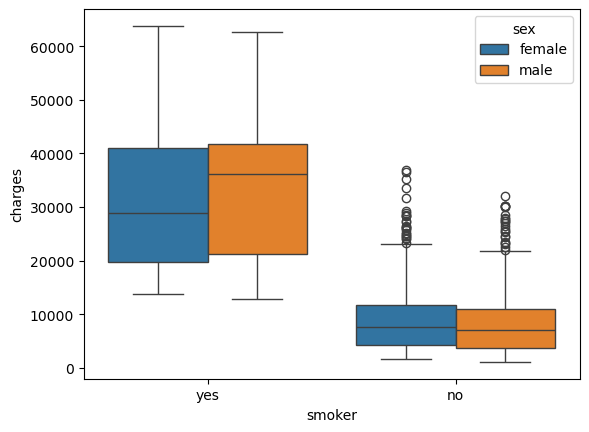

In [23]:
sns.boxplot(x = 'smoker', y = 'charges', hue = 'sex', data = df)

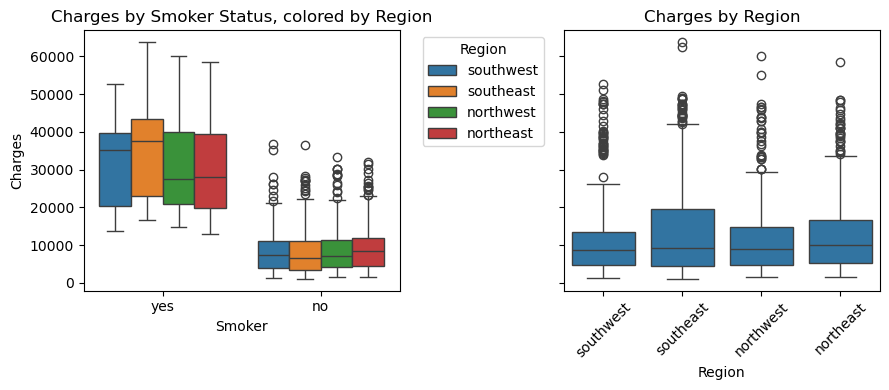

In [24]:
# Create a figure with 1 row and 2 columns, sharing the y-axis for direct comparison
fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharey=True)

# 1) Boxplot: charges by smoker, colored by region
sns.boxplot(
    data=df,
    x='smoker',
    y='charges',
    hue='region',
    ax=axes[0]
)
axes[0].set_title('Charges by Smoker Status, colored by Region')
axes[0].set_xlabel('Smoker')
axes[0].set_ylabel('Charges')
# Adjust legend: move it outside or make it smaller so it doesn’t overlap
axes[0].legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
# If many regions, consider removing legend from plot and showing separately:
# handles, labels = axes[0].get_legend_handles_labels()
# fig.legend(handles, labels, title='Region', loc='upper center', ncol=len(labels))

# 2) Boxplot: charges by region
sns.boxplot(
    data=df,
    x='region',
    y='charges',
    ax=axes[1]
)
axes[1].set_title('Charges by Region')
axes[1].set_xlabel('Region')
# Optionally rotate x-tick labels if region names are long or many:
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel('')  # y-label already on the left plot

# Layout adjustments
plt.tight_layout()
plt.show()


In [25]:
# df['bmi_log'] = np.log(data.bmi)
# df['log_charges'] = np.log(data.charges)
# df['log_age'] = np.log(data.age)

In [26]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges',
       'smoker_code', 'sex_code', 'region_northwest', 'region_southeast',
       'region_southwest'],
      dtype='object')

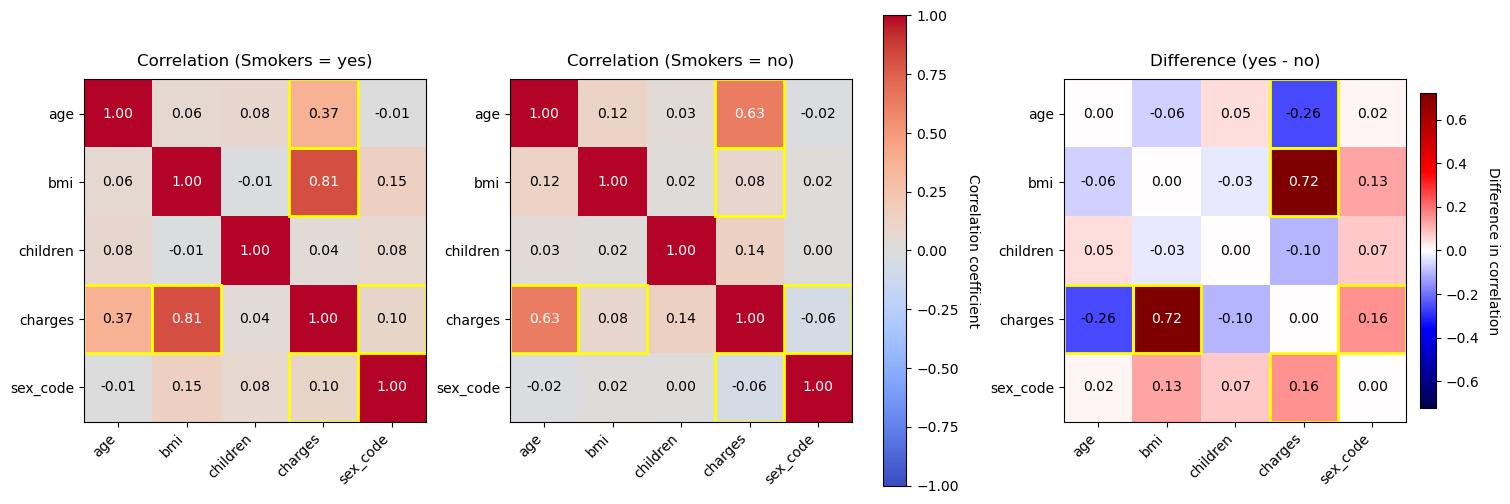

In [27]:
cols = ['age', 'bmi', 'children', 'charges', 'sex_code']
corr_yes = df[df['smoker'] == 'yes'][cols].corr()
corr_no  = df[df['smoker'] == 'no'][cols].corr()
diff_corr = corr_yes - corr_no

# Compute threshold
diff_abs = diff_corr.abs()
mask_diag = np.eye(len(cols), dtype=bool)
diff_abs_no_diag = diff_abs.mask(mask_diag)
threshold = diff_abs_no_diag.stack().quantile(0.75)

# 3. Use constrained_layout=True and a wider figure
fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 5),            # wider figure space
    constrained_layout=True      # automatically handle padding
)
vmin, vmax = -1, 1
vars_ = cols

def plot_corr_with_highlights(ax, corr_mat, title):
    im = ax.imshow(corr_mat, vmin=vmin, vmax=vmax, cmap='coolwarm')
    ax.set_title(title, fontsize=12, pad=10)
    ax.set_xticks(np.arange(len(vars_)))
    ax.set_yticks(np.arange(len(vars_)))
    ax.set_xticklabels(vars_, rotation=45, ha='right')
    ax.set_yticklabels(vars_)
    for i in range(len(vars_)):
        for j in range(len(vars_)):
            val = corr_mat.iloc[i, j]
            text_color = 'white' if abs(val) > 0.5 else 'black'
            ax.text(j, i, f"{val:.2f}", ha='center', va='center', color=text_color)
            if abs(diff_corr.iloc[i, j]) >= threshold and i != j:
                rect = Rectangle((j - 0.5, i - 0.5), 1, 1,
                                 fill=False, edgecolor='yellow', linewidth=2)
                ax.add_patch(rect)
    return im

im0 = plot_corr_with_highlights(axes[0], corr_yes, 'Correlation (Smokers = yes)')
im1 = plot_corr_with_highlights(axes[1], corr_no,  'Correlation (Smokers = no)')

# Difference plot
max_diff = np.max(np.abs(diff_corr.values))
im2 = axes[2].imshow(diff_corr, vmin=-max_diff, vmax=max_diff, cmap='seismic')
axes[2].set_title('Difference (yes - no)', fontsize=12, pad=10)
axes[2].set_xticks(np.arange(len(vars_)))
axes[2].set_yticks(np.arange(len(vars_)))
axes[2].set_xticklabels(vars_, rotation=45, ha='right')
axes[2].set_yticklabels(vars_)
for i in range(len(vars_)):
    for j in range(len(vars_)):
        val = diff_corr.iloc[i, j]
        text_color = 'white' if abs(val) > max_diff * 0.5 else 'black'
        axes[2].text(j, i, f"{val:.2f}", ha='center', va='center', color=text_color)
        if abs(val) >= threshold and i != j:
            rect = Rectangle((j - 0.5, i - 0.5), 1, 1,
                             fill=False, edgecolor='yellow', linewidth=2)
            axes[2].add_patch(rect)

# Shared colorbar for first two
cbar = fig.colorbar(im0, ax=axes[:2].tolist(),
                    orientation='vertical', fraction=0.046, pad=0.04)
cbar.set_label('Correlation coefficient', rotation=270, labelpad=15)

# Colorbar for diff
cbar2 = fig.colorbar(im2, ax=axes[2],
                     orientation='vertical', fraction=0.046, pad=0.04)
cbar2.set_label('Difference in correlation', rotation=270, labelpad=15)

plt.show()


Do smokers and non‑smokers differ in average medical charges?

In [28]:
sm = df.loc[df.smoker=='yes','charges']
ns = df.loc[df.smoker=='no', 'charges']

u_stat, p_val = mannwhitneyu(sm, ns, alternative='two-sided')
print(f"Mann–Whitney U = {u_stat:.1f}, p = {p_val:.3e}")


Mann–Whitney U = 283859.0, p = 5.747e-130


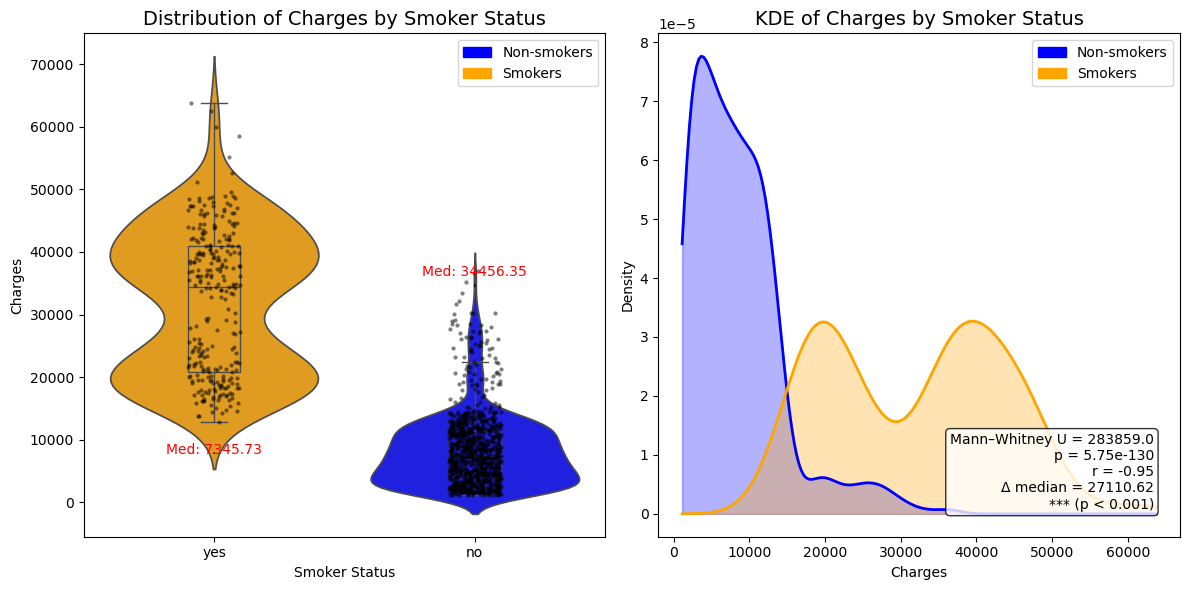

In [29]:
# 1. Extract groups on raw charges
sm = df.loc[df.smoker == 'yes', 'charges'].to_numpy()
ns = df.loc[df.smoker == 'no',  'charges'].to_numpy()
n1, n2     = len(sm), len(ns)

# 2. Mann–Whitney U and rank‐biserial r
u_stat, p_val = mannwhitneyu(sm, ns, alternative='two-sided')
r             = 1 - (2 * u_stat) / (n1 * n2)

# 3. Medians & Δ
median_sm    = np.median(sm)
median_ns    = np.median(ns)
diff_median  = median_sm - median_ns

# 4. Significance stars
if p_val < 0.001:
    signif = '*** (p < 0.001)'
elif p_val < 0.01:
    signif = '** (p < 0.01)'
elif p_val < 0.05:
    signif = '* (p < 0.05)'
else:
    signif = f'n.s. (p = {p_val:.3f})'

anno_text = (
    f"Mann–Whitney U = {u_stat:.1f}\n"
    f"p = {p_val:.2e}\n"
    f"r = {r:.2f}\n"
    f"Δ median = {diff_median:.2f}\n"
    f"{signif}"
)

# 5. Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
palette = {'no': 'blue', 'yes': 'orange'}

# Legend handles
legend_handles = [
    Patch(color=palette['no'],  label='Non‑smokers'),
    Patch(color=palette['yes'], label='Smokers')
]

# Left panel: violin + box + strip
ax = axes[0]
sns.violinplot(
    x='smoker', y='charges', data=df,
    hue='smoker', palette=palette,
    inner=None, dodge=False,
    legend=False, ax=ax
)
sns.boxplot(
    x='smoker', y='charges', data=df,
    hue='smoker', palette=palette,
    width=0.2, showcaps=True,
    boxprops={'facecolor':'none'},
    showfliers=False,
    dodge=False, legend=False,
    ax=ax
)
sns.stripplot(
    x='smoker', y='charges', data=df,
    size=3, color='k', alpha=0.5,
    jitter=True, order=['no','yes'], ax=ax
)
ax.set_title('Distribution of Charges by Smoker Status', fontsize=14)
ax.set_xlabel('Smoker Status')
ax.set_ylabel('Charges')

# Annotate medians
ax.annotate(f"Med: {median_ns:.2f}",
            xy=(0, median_ns),
            xytext=(0, median_ns*1.05),
            ha='center', color='red', fontsize=10,
            arrowprops=dict(arrowstyle='-'))
ax.annotate(f"Med: {median_sm:.2f}",
            xy=(1, median_sm),
            xytext=(1, median_sm*1.05),
            ha='center', color='red', fontsize=10,
            arrowprops=dict(arrowstyle='-'))

ax.legend(handles=legend_handles, loc='upper right')

# Right panel: KDE
ax = axes[1]
all_data = np.concatenate([ns, sm])
grid     = np.linspace(all_data.min() - 0.5,
                       all_data.max() + 0.5, 200)

kde_ns = gaussian_kde(ns)
kde_sm = gaussian_kde(sm)

ax.plot(grid, kde_ns(grid), label='Non‑smokers',
        color=palette['no'],  linewidth=2)
ax.fill_between(grid, kde_ns(grid), alpha=0.3,
                color=palette['no'])
ax.plot(grid, kde_sm(grid), label='Smokers',
        color=palette['yes'], linewidth=2)
ax.fill_between(grid, kde_sm(grid), alpha=0.3,
                color=palette['yes'])

ax.set_title('KDE of Charges by Smoker Status', fontsize=14)
ax.set_xlabel('Charges')
ax.set_ylabel('Density')
ax.legend(handles=legend_handles, loc='upper right')

# Add test annotation
ax.text(0.95, 0.05, anno_text,
        transform=ax.transAxes,
        ha='right', va='bottom',
        fontsize=10,
        bbox=dict(boxstyle='round',
                  facecolor='white',
                  alpha=0.8))

plt.tight_layout()
plt.show()


Based these findings, I decided to use two regression models one for smokers and non-smmokers

In [30]:
# df.columns

In [31]:
# df.columns

In [32]:
# df[['age', 'bmi', 'children', 'charges',
       # 'smoker_code', 'sex_code']].corr()

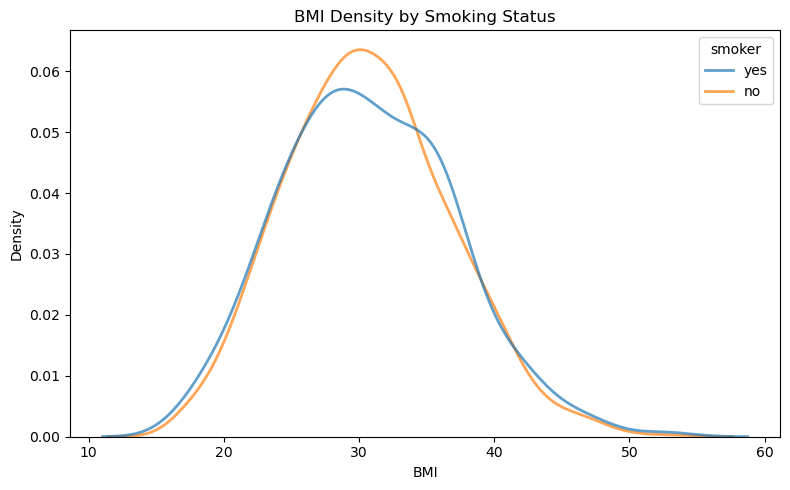

In [33]:
plt.figure(figsize=(8, 5))
sns.kdeplot(
    data=df,
    x="bmi",
    hue="smoker",
    fill=False,
    common_norm=False,
    alpha=0.7,
    linewidth=2
)
plt.title("BMI Density by Smoking Status")
plt.xlabel("BMI")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

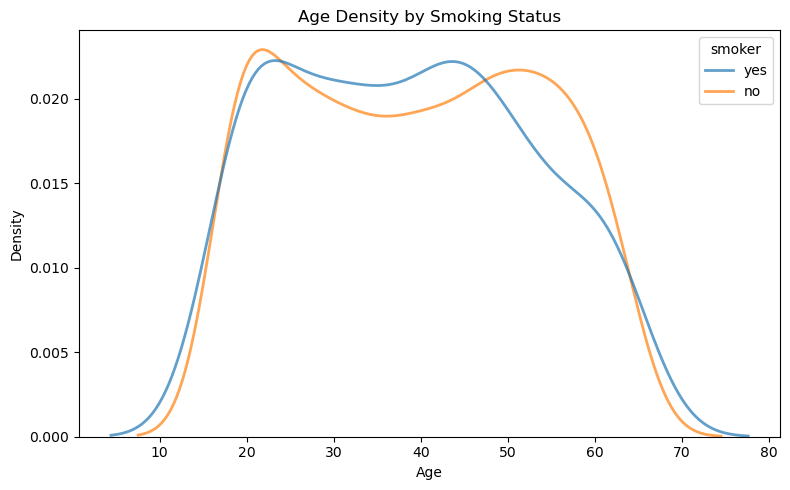

In [34]:
plt.figure(figsize=(8, 5))
sns.kdeplot(
    data=df,
    x="age",
    hue="smoker",
    fill=False,
    common_norm=False,
    alpha=0.7,
    linewidth=2
)
plt.title("Age Density by Smoking Status")
plt.xlabel("Age")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

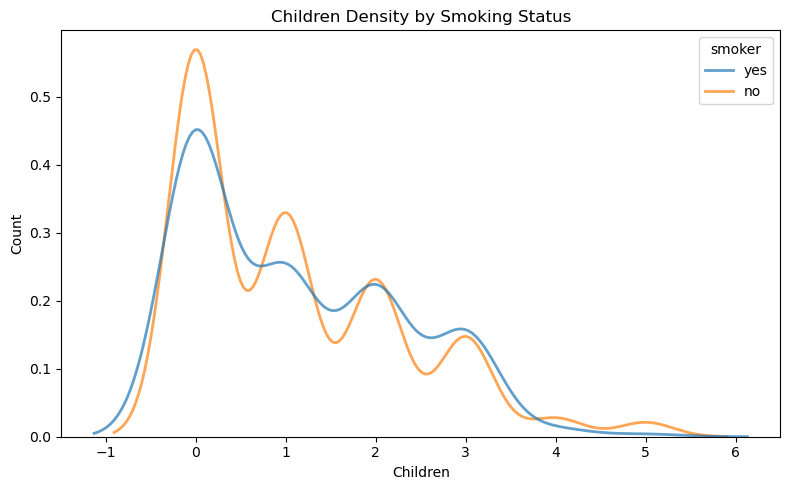

In [35]:
plt.figure(figsize=(8, 5))
sns.kdeplot(
    data=df,
    x="children",
    hue="smoker",
    fill=False,
    common_norm=False,
    alpha=0.7,
    linewidth=2
)
plt.title("Children Density by Smoking Status")
plt.xlabel("Children")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [36]:
scaler = StandardScaler()

In [37]:
smokers = df[df['smoker'] == 'yes'] [['age', 'children', 'sex_code', 'charges', 'bmi', 'region_northwest', 'region_southeast','region_southwest']]
non_smokers = df[df['smoker'] == 'no'] [['age', 'children', 'sex_code', 'charges', 'bmi', 'region_northwest', 'region_southeast','region_southwest']]

In [38]:


# Step 1: Calculate Z-scores for 'charges'
z_scores = np.abs(zscore(smokers['charges']))

# Step 2: Set threshold 
threshold = 2.5

# Step 3: Filter the DataFrame
smokers_clean = smokers[z_scores < threshold].copy()

# Optional: Show before and after
print("Original size:", smokers.shape)
print("Cleaned size:", smokers_clean.shape)

Original size: (274, 8)
Cleaned size: (272, 8)


In [39]:


#Calculate Z-scores for 'charges'
z_scores_ns = np.abs(zscore(non_smokers['charges']))

#Filter the DataFrame
non_smokers_clean = non_smokers[z_scores_ns < threshold].copy()

# Optional: Show before and after
print("Original size:", non_smokers.shape)
print("Cleaned size:", non_smokers_clean.shape)

Original size: (1063, 8)
Cleaned size: (1022, 8)


In [40]:
# smokers = smokers_clean[['age', 'children', 'sex_code', 'charges', 'bmi', 'region_northwest',
#        'region_southeast', 'region_southwest']]

Transformations on smokers

In [41]:
smokers_clean['log_bmi'] = np.log(smokers_clean.bmi)
smokers_clean['log_charges'] = np.log(smokers_clean.charges)
smokers_clean['age'] = smokers_clean.age**.5
smokers_clean['log_children'] = np.log(smokers_clean.children + 1)

Regression analysis for the non-smokers

In [42]:
y_s = smokers_clean[['log_charges']]
X_s = smokers_clean[['age', 'sex_code', 'log_children', 'region_northwest', 'region_southeast',
       'region_southwest', 'log_bmi']]

In [43]:
X_s= scaler.fit_transform(X_s)
X_s = pd.DataFrame(X_s, columns = ['age', 'sex_code', 'log_children', 'region_northwest', 'region_southeast',
       'region_southwest', 'log_bmi'])

In [44]:
X_s = st.add_constant(X_s)


In [45]:
y_s.shape

(272, 1)

In [46]:
X_s = X_s.reset_index(drop=True)
y_s = y_s.reset_index(drop=True)
reg_model_s = st.OLS(y_s, X_s).fit()

robust_se_s = reg_model_s.get_robustcov_results(cov_type='HC0')

print(robust_se_s.summary())

                            OLS Regression Results                            
Dep. Variable:            log_charges   R-squared:                       0.775
Model:                            OLS   Adj. R-squared:                  0.769
Method:                 Least Squares   F-statistic:                     118.6
Date:                Mon, 07 Jul 2025   Prob (F-statistic):           9.42e-78
Time:                        14:44:53   Log-Likelihood:                 78.030
No. Observations:                 272   AIC:                            -140.1
Df Residuals:                     264   BIC:                            -111.2
Df Model:                           7                                         
Covariance Type:                  HC0                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               10.2986      0.011  

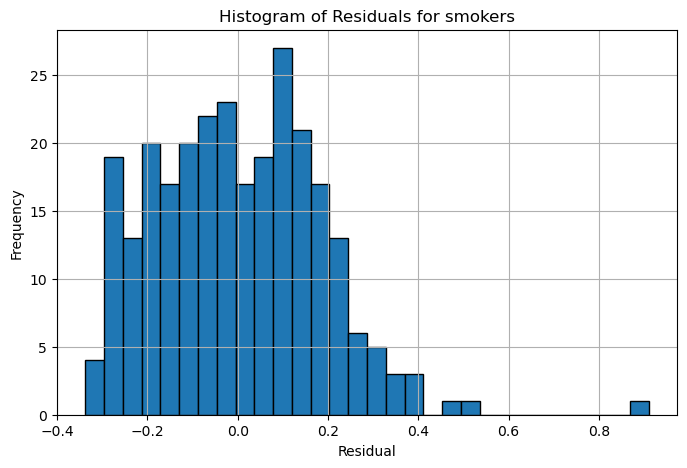

In [47]:
residuals_s = reg_model_s.resid

plt.figure(figsize=(8, 5))
plt.hist(residuals_s, bins=30, edgecolor='black')
plt.title('Histogram of Residuals for smokers')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

<Figure size 600x600 with 0 Axes>

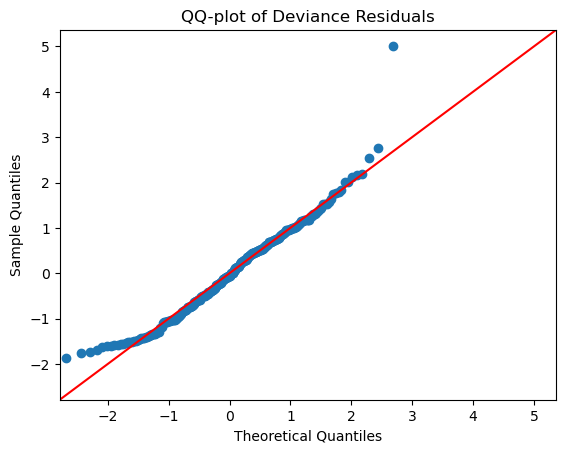

In [48]:
plt.figure(figsize=(6, 6))
st.qqplot(residuals_s, line='45', fit=True)
plt.title('QQ-plot of Deviance Residuals')
plt.show()

In [49]:
# non_smokers = non_smokers_clean[['age', 'children', 'sex_code', 'charges', 'bmi', 'region_northwest',
#        'region_southeast', 'region_southwest']]

Transfomations on the non-smokers

In [50]:
non_smokers_clean['log_bmi'] = np.log(non_smokers_clean['bmi'])
non_smokers_clean['log_charges'] = np.log(non_smokers_clean['charges'])
non_smokers_clean['age'] = non_smokers_clean['age']**.5
non_smokers_clean['log_children'] = np.log(non_smokers_clean['children'] + 1)

In [51]:
y_ns = non_smokers_clean['log_charges']
X_ns = non_smokers_clean[['age', 'sex_code', 'log_children', 'log_bmi', 'region_northwest', 'region_southeast',
       'region_southwest']]

In [52]:
X_ns = scaler.fit_transform(X_ns)
X_ns = pd.DataFrame(X_ns, columns = ['age', 'sex_code', 'log_children', 'log_bmi', 'region_northwest', 'region_southeast',
       'region_southwest'])

In [53]:
X_ns = st.add_constant(X_ns)


In [54]:
X_ns = X_ns.reset_index(drop=True)
y_ns = y_ns.reset_index(drop=True)
reg_model_ns = st.OLS(y_ns, X_ns).fit()

robust_se_ns = reg_model_ns.get_robustcov_results(cov_type='HC0')

print(robust_se_ns.summary())

                            OLS Regression Results                            
Dep. Variable:            log_charges   R-squared:                       0.746
Model:                            OLS   Adj. R-squared:                  0.744
Method:                 Least Squares   F-statistic:                     303.8
Date:                Mon, 07 Jul 2025   Prob (F-statistic):          8.04e-244
Time:                        14:44:54   Log-Likelihood:                -382.91
No. Observations:                1022   AIC:                             781.8
Df Residuals:                    1014   BIC:                             821.3
Df Model:                           7                                         
Covariance Type:                  HC0                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                8.7317      0.011  

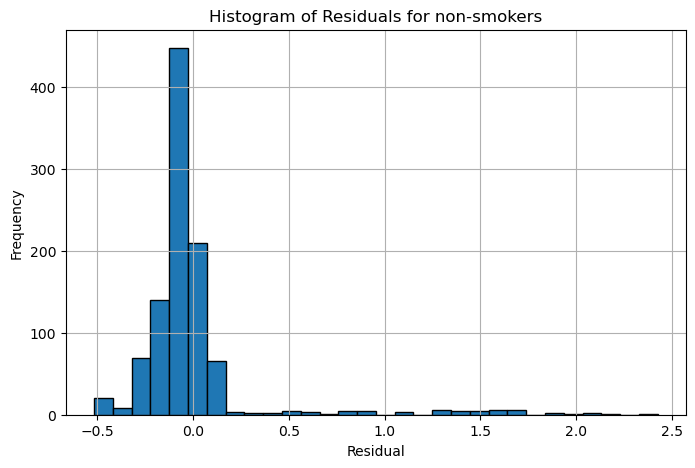

In [55]:
residuals_ns = reg_model_ns.resid

plt.figure(figsize=(8, 5))
plt.hist(residuals_ns, bins=30, edgecolor='black')
plt.title('Histogram of Residuals for non-smokers')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

<Figure size 600x600 with 0 Axes>

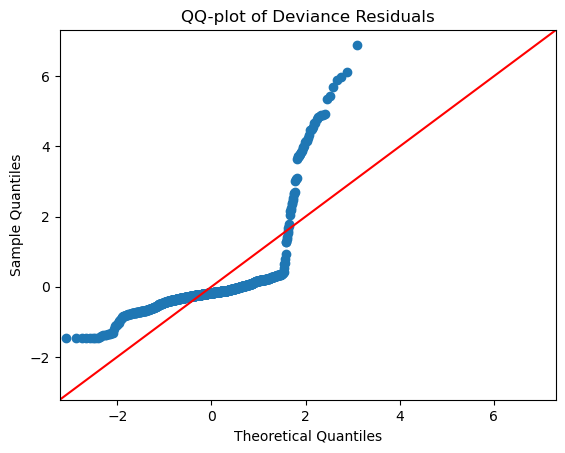

In [56]:
plt.figure(figsize=(6, 6))
st.qqplot(residuals_ns, line='45', fit=True)
plt.title('QQ-plot of Deviance Residuals')
plt.show()

Predictive Models

In [57]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges',
       'smoker_code', 'sex_code', 'region_northwest', 'region_southeast',
       'region_southwest'],
      dtype='object')

In [58]:
X = df[['age','bmi','children',
       'smoker_code', 'sex_code', 'region_northwest', 'region_southeast',
       'region_southwest']].copy()
y = np.log(df.charges)

In [59]:
X['bmi'] = np.log(X['bmi'])
X['children'] = np.log(X['children'] + 1)

In [60]:
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, stratify=X['smoker_code'], random_state=1, test_size = .2)

In [61]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.3, random_state=1, stratify=X_train_val['smoker_code']
)

In [62]:
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

In [63]:

from sklearn.model_selection import cross_val_score, KFold

cv = KFold(n_splits=6, shuffle=True, random_state=1)

alpha_values = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
ridge_scores = []

for alpha in alpha_values:
    ridge = Ridge(alpha=alpha)
    # scoring='neg_mean_squared_error' → higher (less negative) is better
    cv_score = cross_val_score(
        ridge,
        X_val_scaled, y_val,
        cv=cv,
        scoring='r2',
        n_jobs=-1
    ).mean()
    ridge_scores.append(cv_score)

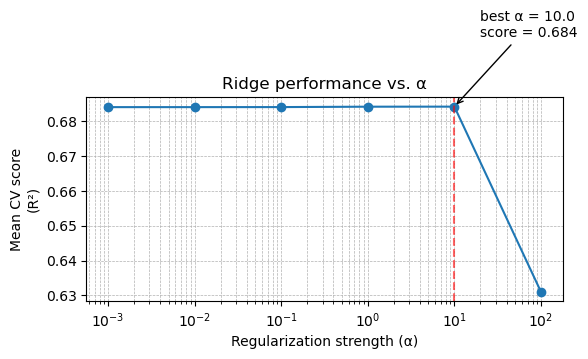

In [64]:

# Convert to arrays for easy indexing
alphas = np.array(alpha_values)
scores = np.array(ridge_scores)

# Find best alpha (highest score)
best_idx = scores.argmax()
best_alpha = alphas[best_idx]
best_score = scores[best_idx]

# Plot
plt.figure(figsize=(6, 4))
plt.plot(alphas, scores, marker='o')
plt.xscale('log')  # since alpha is on a log scale
plt.axvline(best_alpha, color='red', ls='--', alpha=0.6)  
plt.annotate(
    f'best α = {best_alpha}\nscore = {best_score:.3f}',
    xy=(best_alpha, best_score),
    xytext=(best_alpha * 2, best_score + 0.02),
    arrowprops=dict(arrowstyle='->')
)

plt.xlabel('Regularization strength (α)')
plt.ylabel('Mean CV score\n(R²)')
plt.title('Ridge performance vs. α')
plt.grid(True, which='both', ls='--', lw=0.5)
plt.tight_layout()
plt.show()


In [65]:
# Combine train + val for final training
X_combined = np.vstack([X_train_scaled, X_val_scaled])
y_combined = np.concatenate([y_train, y_val])
ridge = Ridge(alpha = best_alpha).fit(X_combined, y_combined)
y_pred_test = ridge.predict(X_test_scaled)
print(f'The mean squared error for Ridge regression is: {mean_squared_error(y_test, y_pred_test)}')

The mean squared error for Ridge regression is: 0.1646049415653783


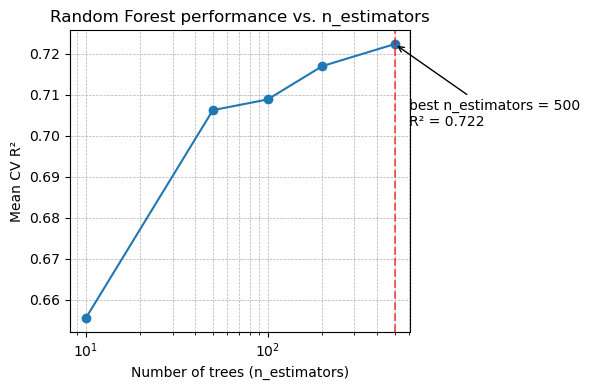

In [66]:
# 1) Define your CV splitter
cv = KFold(n_splits=6, shuffle=True, random_state=1)

# 2) Choose a grid of n_estimators to try
n_trees = [10, 50, 100, 200, 500]
rf_scores = []

# 3) Loop over each value, compute CV R²
for n in n_trees:
    rf = RandomForestRegressor(
        n_estimators=n,
        max_features='sqrt',    # or float/int
        random_state=1,
        n_jobs=-1
    )
    cv_score = cross_val_score(
        rf,
        X_val_scaled, y_val,
        cv=cv,
        scoring='r2'
    ).mean()
    rf_scores.append(cv_score)

# 4) Convert to arrays for easy plotting
trees = np.array(n_trees)
scores = np.array(rf_scores)

# 5) Identify best setting
best_idx    = scores.argmax()
best_trees  = trees[best_idx]
best_score  = scores[best_idx]

# 6) Plot performance vs. n_estimators
plt.figure(figsize=(6, 4))
plt.plot(trees, scores, marker='o')
plt.axvline(best_trees, color='red', ls='--', alpha=0.6)
plt.annotate(
    f'best n_estimators = {best_trees}\nR² = {best_score:.3f}',
    xy=(best_trees, best_score),
    xytext=(best_trees*1.2, best_score-0.02),
    arrowprops=dict(arrowstyle='->')
)

plt.xscale('log')
plt.xlabel('Number of trees (n_estimators)')
plt.ylabel('Mean CV R²')
plt.title('Random Forest performance vs. n_estimators')
plt.grid(True, which='both', ls='--', lw=0.5)
plt.tight_layout()
plt.show()


In [67]:
ridge = Ridge(alpha = 10.0).fit(X_combined, y_combined)
y_pred_test_ridge = ridge.predict(X_test_scaled)
print(f'The mean squared error for Ridge regression is: {mean_squared_error(y_test, y_pred_test)}')

The mean squared error for Ridge regression is: 0.1646049415653783


In [68]:
random_forest_regressor = RandomForestRegressor(n_estimators= best_trees).fit(X_combined, y_combined)
y_pred_test_rf = random_forest_regressor.predict(X_test_scaled)
print(f'The mean squared error for Random forest regression is: {mean_squared_error(y_test, y_pred_test_rf)}')

The mean squared error for Random forest regression is: 0.15136742555606064


In [69]:
results = pd.DataFrame({
    "Model": ["Ridge Regression", "Random Forest"],
    "Parameters": [f"alpha=10.0", f"n_estimators={best_trees}"],
    "Test MSE": [
        mean_squared_error(y_test, y_pred_test_ridge),
        mean_squared_error(y_test, y_pred_test_rf)
    ]
})

In [70]:
results

,Model,Parameters,Test MSE
0,Ridge Regression,alpha=10.0,0.164605
1,Random Forest,n_estimators=500,0.151367
